In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np
import matplotlib.dates as mdates

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive, utilities

In [2]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)
plotting_style = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle'

# Glider Data Processing and Analysis

This notebook is dedicated to **loading, processing, and analyzing oceanographic glider datasets** from the University of Washington Seaglider program. The data corresponds to missions conducted near the Faroe Islands and are publicly available from NOAA’s National Centers for Environmental Information (NCEI).

---

## Glider Missions

- **Overview:** [Seaglider Faroes Missions](https://iop.apl.washington.edu/seaglider/index.php?mission=Faroes)  
- **Data Server:** [NOAA NCEI Seaglider Archive](https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/)

The missions span from 2006 to 2009 and include multiple gliders (e.g., 005, 016, 101) and mission deployments. Below is a detailed breakdown of available missions and folder identifiers:

### November 2006
- 016 early recovered (124 dives) — `016/20061112` bad bad resolution data
- 101 full mission (578 dives) — `101/20061112` bad resolution of data
- 102 full mission (630 dives) — `102/20061112`

### February 2007
- 103 full mission (679 dives) — `103/20070218`
- 105 FSC section (125 dives) — _no folder_
- 104 early recovery (70 dives) — _no folder_

### June 2007
- 101 full mission (453 dives) — `101/20070609`
- 102 early recovery (22 dives) — _no folder_

### September 2007
- 012 partial mission (188 dives) — `012/20070831`
- 104 full mission (371 dives) — `104/20070901`
- 105 full mission (373 dives) — _no folder_

### November 2007
- 016 (452 dives) — `016/20071113`
- 102 (454 dives) — `102/20071113`
- 103 (524 dives) — `103/20071113`

### February 2008
- 014 (70 dives) — `014/20080214`   not at IFR
- 104 (112 dives) — `104/20080214`

### June 2008
- 102 (5 dives) — _no folder_
- 005 (386 dives) — `005/20080606`
- 016 (421 dives) — `016/20080607`

### August 2008
- 105 (13 dives) — _no folder_
- 103 (10 dives) — _no folder_
- 014 (439 dives) — `014/20080222` (_folder name misleading_)

### November 2008
- 104 (1 dive) — _no folder_  
- 101 (338 dives) — `101/20081108`
- 005 (486 dives) — `005/20081106`

### February 2009
- 103 (481 dives) — `103/20090223`
- 104 (4 dives) — _no folder_

### June 2009
- 016 (297 dives) — `016/20090605`
- 105 (346 dives) — _no folder_
- 005 (464 dives) — `005/20090829`

---

## Notebook Workflow

This notebook performs the following key steps:

1. **Data Loading and Conversion:**  
   The raw glider mission data is loaded from the NOAA server and converted into the **OG1 standardized format**, facilitating streamlined analysis across multiple missions.

2. **Visualization and Exploration:**  
   Various types of visualizations are created to explore the glider data, including:
   - **Glider tracks** (map view)
   - **Profile plots** (e.g., temperature/salinity vs. depth)
   - **Section plots** (along-track interpolations)
   - **Technical diagnostics** (e.g., battery voltage, pitch, roll)

3. **Mixed Layer Depth (MLD) Estimation:**  
   The **mixed layer depth** is computed using two separate methods to compare results and assess robustness:
   - **Fixed density threshold approach**
   - **Gradient-based approach**

These analyses support a better understanding of the hydrographic conditions during the glider missions and contribute to broader oceanographic research near the Faroe Islands.

# 1. Data Loading and Conversion

### 1.1 Choose glider mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=1, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('09/07 (dives: 188)',), value='09/07 (dives: 188)')

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/012/20070831/


In [4]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.2 (Down-)loading the data into a list of .nc files and then convert into OG1 format. 
The list of datasets is concatented into one dataset and then saved at the mission path 

In [9]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


ConnectionError: HTTPSConnectionPool(host='www.ncei.noaa.gov', port=443): Max retries exceeded with url: /data/oceans/glider/seaglider/uw/012/20070831/ (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x12eb6ac10>: Failed to establish a new connection: [Errno 9] Bad file descriptor'))

In [ ]:
variables_needed = ['TIME','LONGITUDE','LATITUDE','PROFILE_NUMBER','DIVE_NUMBER', # measurment point specific
                    'PITCH', 'ROLL','HEADING',
                    'DEPTH','PRES',
                    'GLIDER_VERT_VELO_MODEL','GLIDER_HORZ_VELO_MODEL','GLIDE_SPEED','GLIDE_SPEED_QC', # vertical and horizontal velocity with quality control
                    'TEMP','TEMP_QC','PSAL','PSAL_QC','PSAL_RAW','PSAL_RAW_QC','TEMP_RAW','TEMP_RAW_QC', # CTD data with extra quality control
                    'SIGTHETA','SIGMA_T','THETA'] # potential density and temperature
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
#ds = tools.add_densities(ds,use_raw=True)
ds = tools.add_densities(ds,use_raw=False)

Converting datasets to OG1 format: 100%|██████████| 112/112 [00:51<00:00,  2.18it/s]


In [8]:
interactive.interactive_profile(ds)

Output()

In [197]:
importlib.reload(tools)
ds = tools.add_vertical_water_velocity(ds, pitch_min = 10, pitch_max = 20)

int64


In [198]:
### cut the dataset to the time period of interest
mask = (ds['TIME'] > np.datetime64('2006-01-01')) & (ds['TIME'] < np.datetime64('2009-12-31'))
ds = ds.where(mask, drop=True)

In [199]:
ds.attrs['Glider'] = selected_glider['glider']
ds.attrs['Mission'] = selected_glider['mission']

In [200]:
### save the OG1 dataset at the destination folder. Check first if the 
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 1.3 Saved dataset is loaded from the mission path

In [5]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')#

# 2. Visualization and Exploration of the data

### 2.1 Plot glider track

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


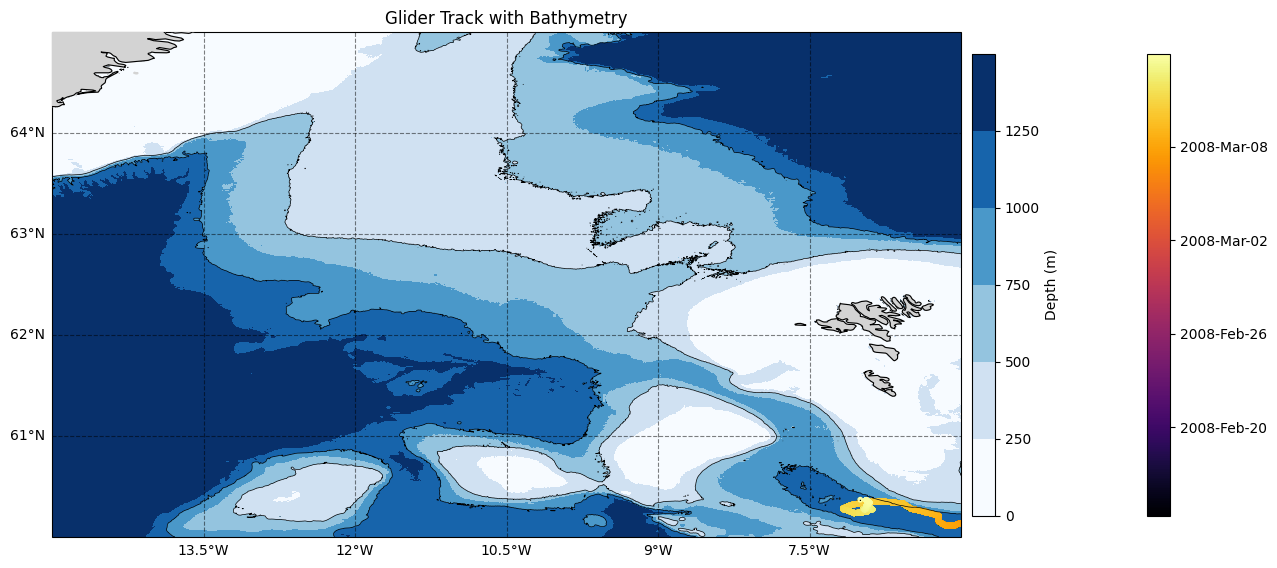

In [202]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
### save the figure as png file
fig.savefig(mission_path + '/glider_track.png', dpi=300, bbox_inches='tight')

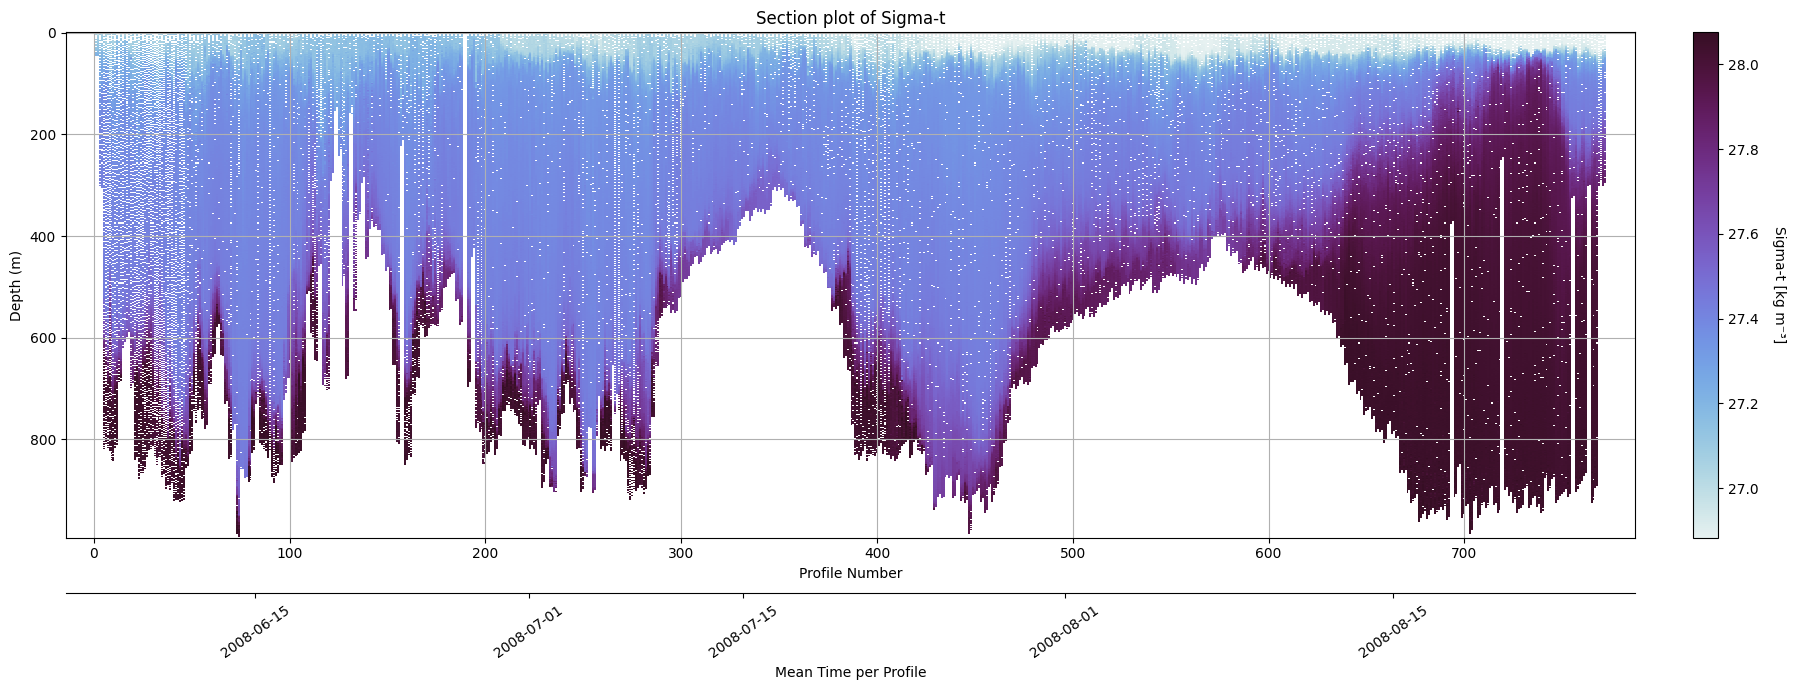

In [206]:
importlib.reload(plotting)
start = 0
end = 100
start = None
end = None
fig, ax = plotting.plot_section(ds, vars=['SIGMA_T'],v_res = 2,start=start, end=end)
### save the figure as png file
fig.savefig(mission_path + '/section_PSAL_TEMP_SIGMA_T.png', dpi=300, bbox_inches='tight')

### 2.2 Plot profiles by chosing up to three different variables

In [6]:
importlib.reload(plotting)
importlib.reload(interactive)
interactive.interactive_profile(ds)

Output()

In [13]:
interactive.interactive_resolution_hist(ds)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile:', options=(np.int64(1), n…

In [14]:
importlib.reload(plotting)
importlib.reload(interactive)
interactive.interactive_mld_profile(ds)

Output()

In [17]:
mld = tools.compute_mld(ds,'SIGMA_T',method = 'threshold', threshold=0.03, use_bins=True, binning = 5)
mld = tools.compute_mld(ds,'SIGMA_1',method = 'CR', threshold=-2, use_bins=True, binning = 5)
importlib.reload(utilities)
mld_ds = utilities.df_to_ds(mld,folder = selected_glider['mission'],glider_name= selected_glider['glider'])

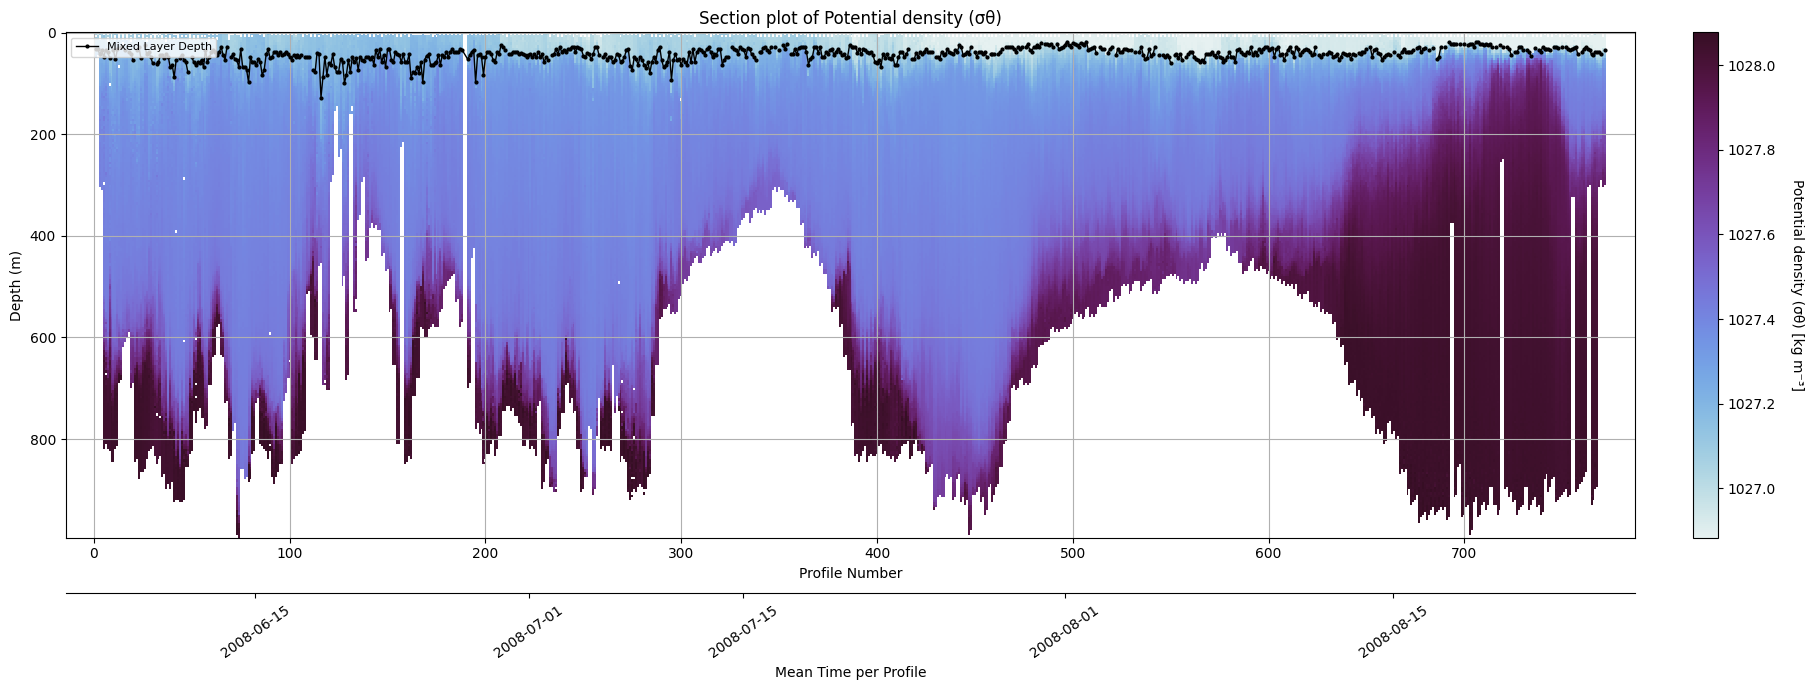

(<Figure size 2000x700 with 2 Axes>,
 [<Axes: title={'center': 'Section plot of Potential density (σθ)'}, xlabel='Profile Number', ylabel='Depth (m)'>])

In [18]:
plotting.plot_section(ds,['SIGTHETA'],mld_df=mld,v_res = 5)

### 2.3 Open ERA5 data to match with glider data

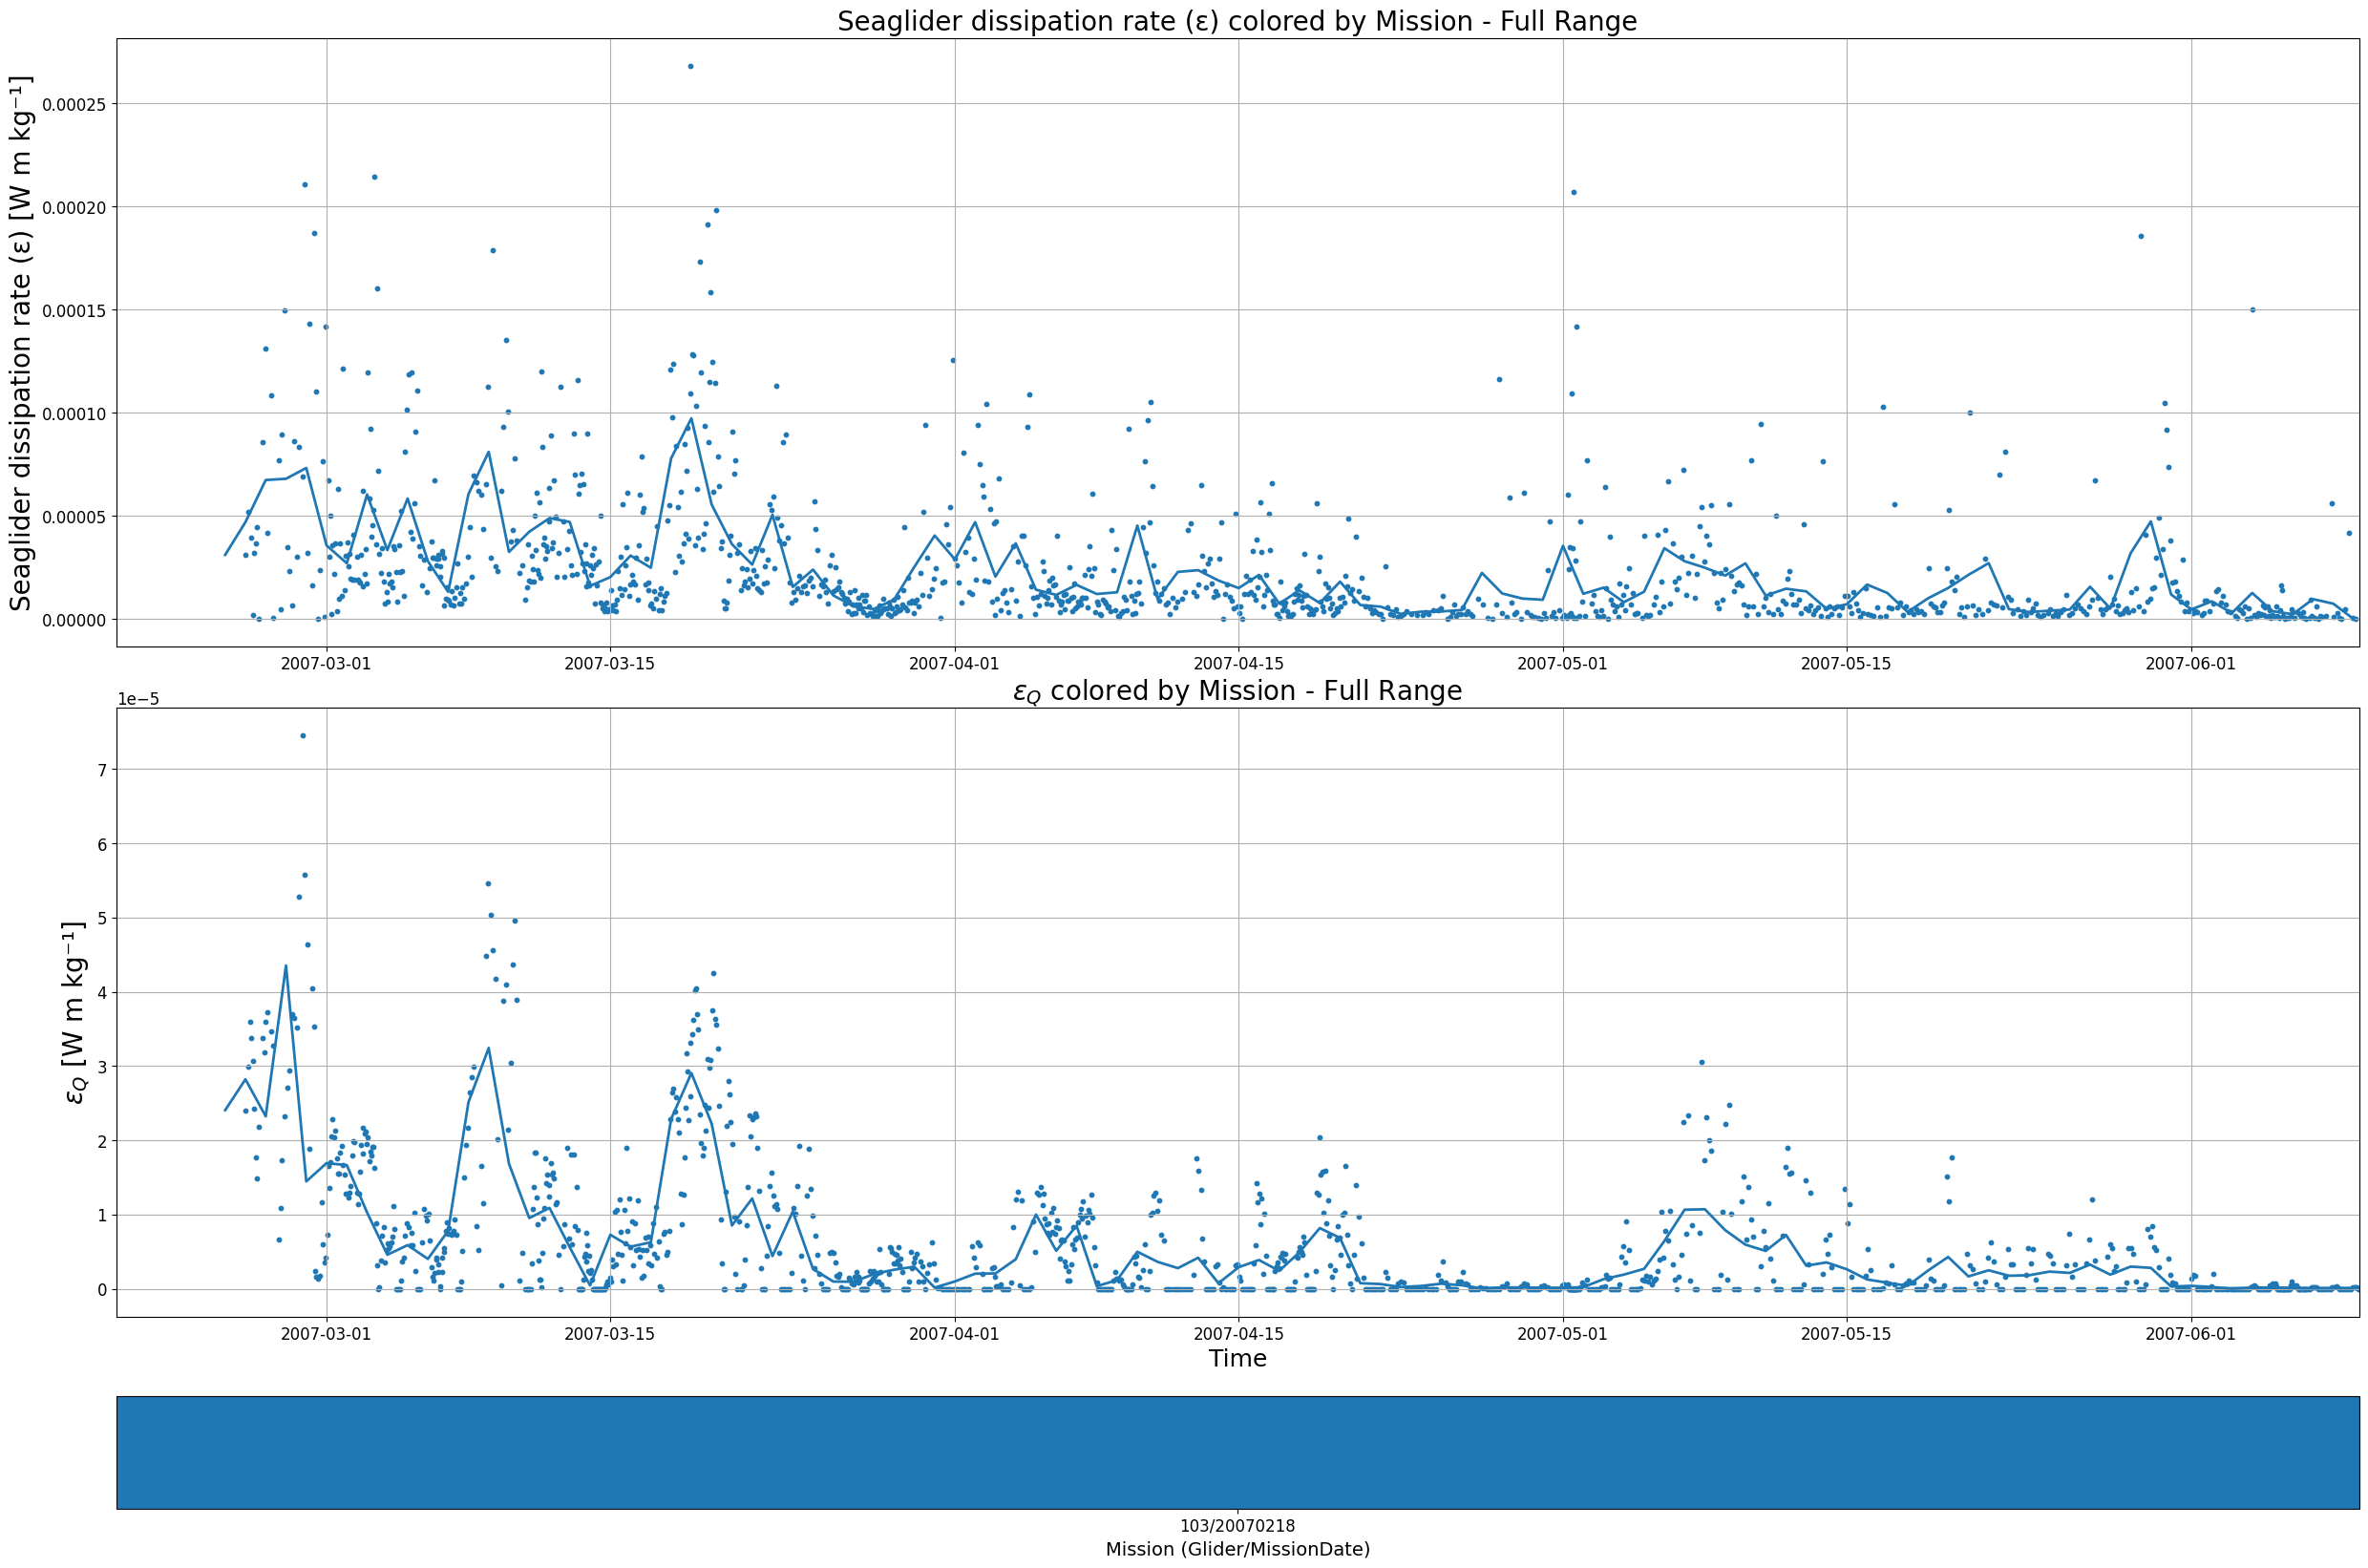

In [444]:
importlib.reload(plotting)
fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['DISSIPATION_LEM_TOTAL','epsilon_Q'], rolling_str='1d',years = None, plot_type="both", mission_cbar=True)
#fig, axes = plotting.plot_var_from_mld(mld_ds, vars = ['epsilon_Q'], rolling_str='1d',years = None, plot_type="both", mission_cbar=True)
#plot_var_from_mld(mld_ds, vars = ['epsilon_Q'], rolling_str='1d',years = None, plot_type="scatter", mission_cbar=True, ax=axes[0])
#[ax.set_ylim(0, 3e-4) for ax in axes]
#[ax.set_yscale('log') for ax in axes]

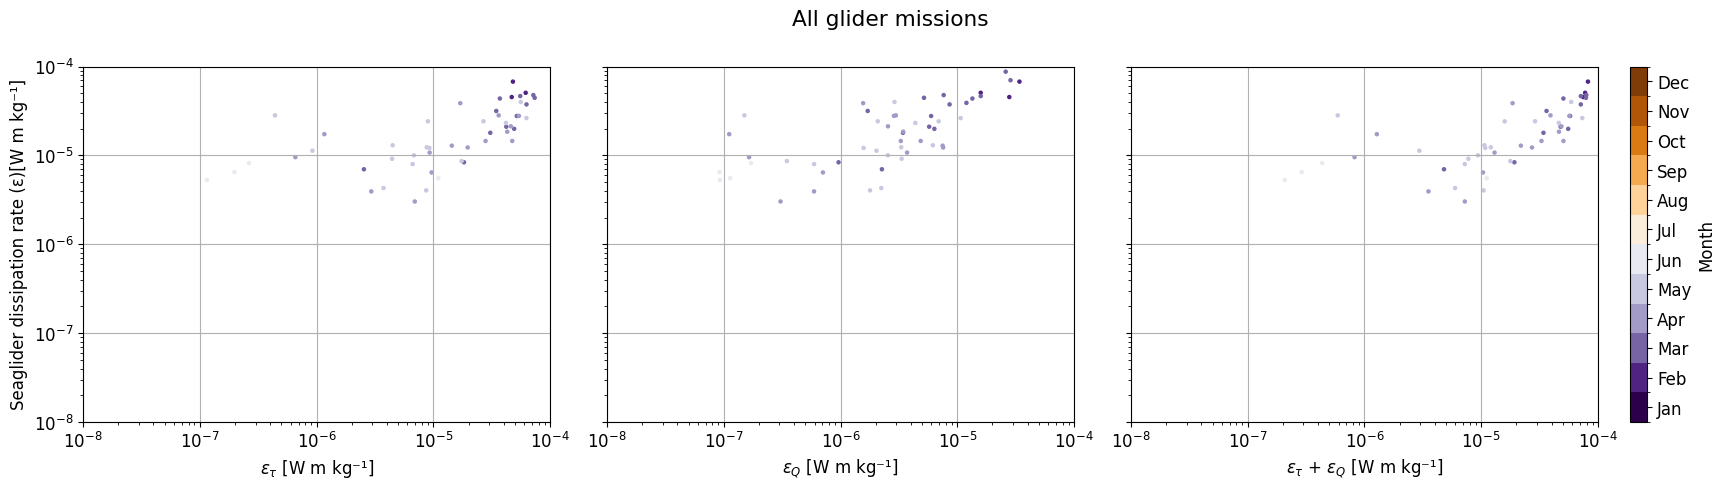

(<Figure size 1800x500 with 4 Axes>,
 array([<Axes: xlabel='$\\epsilon_\\tau$ [W m kg⁻¹]', ylabel='Seaglider dissipation rate (ε)[W m kg⁻¹]'>,
        <Axes: xlabel='$\\epsilon_Q$ [W m kg⁻¹]'>,
        <Axes: xlabel='$\\epsilon_\\tau$ + $\\epsilon_Q$ [W m kg⁻¹]'>],
       dtype=object))

In [446]:
importlib.reload(plotting)
plotting.plot_dissipation_scatter(mld_ds, rolling_str="2d", color_by='TIME')

### 2.4 Calulate the MLD based on different methods and plot it with the density

### 2.3 Plot the MLD, depending on the settings that were chosen and add it in the next step to the dataset

In [424]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

In [14]:
### get the coordinates of the region and create a new dataset with values only from this region
region = get_region()
ds_region = tools.cut_region(ds, region)

In [15]:
importlib.reload(interactive)
bad_profiles = interactive.interactive_bad_profile_checking(ds_region)

In [48]:
### cutting out profile numbers that are not needed
bad_profiles = np.array(bad_profiles)
ds = ds_region.isel(N_MEASUREMENTS=~np.isin(ds_region.PROFILE_NUMBER.values, bad_profiles))

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


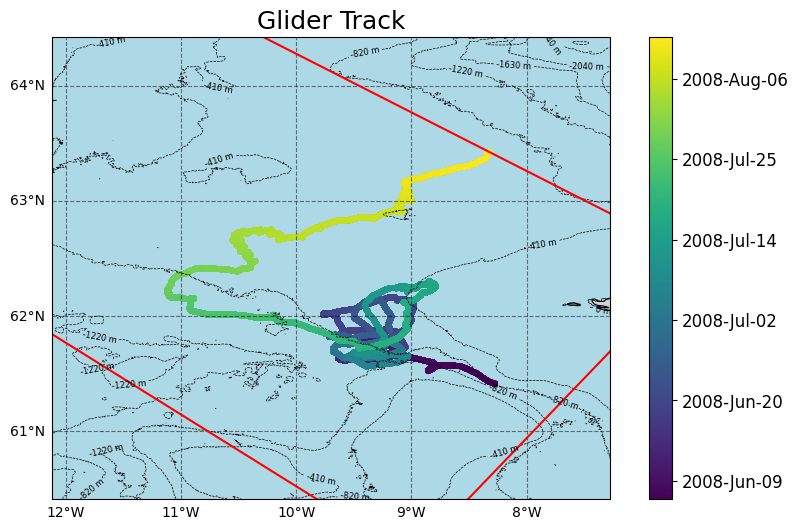

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')